### Imports

In [6]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras import layers, models

In [7]:
print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.21.0
GPU devices: []


### Paths and settings

In [8]:
TRAIN_DIR = Path("../dataset/split/train")
VAL_DIR = Path("../dataset/split/val")
TEST_DIR = Path("../dataset/split/test")

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

### Load datasets

In [9]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True,
    seed=SEED,
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False,
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False,
)

Found 6238 files belonging to 8 classes.
Found 1337 files belonging to 8 classes.
Found 1337 files belonging to 8 classes.


### Check class names

In [10]:
class_names = train_ds.class_names

print("Class names:")
for index, class_name in enumerate(class_names):
    print(index, "->", class_name)

Class names:
0 -> CCI_Caterpillars
1 -> CCI_Leaflets
2 -> Gray Leaf Spot
3 -> Healthy_Leaves
4 -> Leaf Rot
5 -> WCLWD_DryingofLeaflets
6 -> WCLWD_Flaccidity
7 -> WCLWD_Yellowing


### Rebuild class weights safely

In [11]:
weight_lookup = {
    "CCI_Caterpillars": 1.125180,
    "CCI_Leaflets": 1.402428,
    "Gray Leaf Spot": 0.522621,
    "Healthy_Leaves": 9.066860,
    "Leaf Rot": 0.678634,
    "WCLWD_DryingofLeaflets": 1.032781,
    "WCLWD_Flaccidity": 1.042447,
    "WCLWD_Yellowing": 1.027339,
}

class_weights = {
    index: weight_lookup[class_name]
    for index, class_name in enumerate(class_names)
}

class_weights

{0: 1.12518,
 1: 1.402428,
 2: 0.522621,
 3: 9.06686,
 4: 0.678634,
 5: 1.032781,
 6: 1.042447,
 7: 1.027339}

### Improve input pipeline performance

In [12]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

### Data augmentation

In [13]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.10),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
], name="data_augmentation")

### Custom CNN baseline

In [14]:
num_classes = len(class_names)

baseline_model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    data_augmentation,
    layers.Rescaling(1.0 / 255),

    layers.Conv2D(32, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(256, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),

    layers.Dropout(0.3),

    layers.Dense(
        num_classes,
        activation="softmax"
    ),
])

baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 390,472 (1.49 MB)

 Trainable params: 390,472 (1.49 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
baseline_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

### Add callbacks

In [16]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-6,
    ),
]

### Train baseline

In [17]:
EPOCHS = 20

In [ ]:
baseline_history = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks,
) 

Epoch 1/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 574s 3s/step - accuracy: 0.4032 - loss: 1.5150 - val_accuracy: 0.5288 - val_loss: 1.0860 - learning_rate: 0.0010
Epoch 2/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 534s 3s/step - accuracy: 0.5529 - loss: 1.0877 - val_accuracy: 0.5610 - val_loss: 1.0961 - learning_rate: 0.0010
Epoch 3/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 591s 3s/step - accuracy: 0.6271 - loss: 0.8856 - val_accuracy: 0.6051 - val_loss: 0.9063 - learning_rate: 0.0010
Epoch 4/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 594s 3s/step - accuracy: 0.6722 - loss: 0.7627 - val_accuracy: 0.7105 - val_loss: 0.7678 - learning_rate: 0.0010
Epoch 5/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 559s 3s/step - accuracy: 0.7405 - loss: 0.6408 - val_accuracy: 0.6904 - val_loss: 0.7506 - learning_rate: 0.0010
Epoch 6/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 576s 3s/step - accuracy: 0.7873 - loss: 0.5268 - val_accuracy: 0.8437 - val_loss: 0.4030 - learning_rate: 0.0010
Epoch 7/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 555s 3s/step - accuracy: 0.8245 - loss: 0.

In [19]:
baseline_model.save("../backend/trained_models/custom_cnn_baseline.keras")

### Training curves

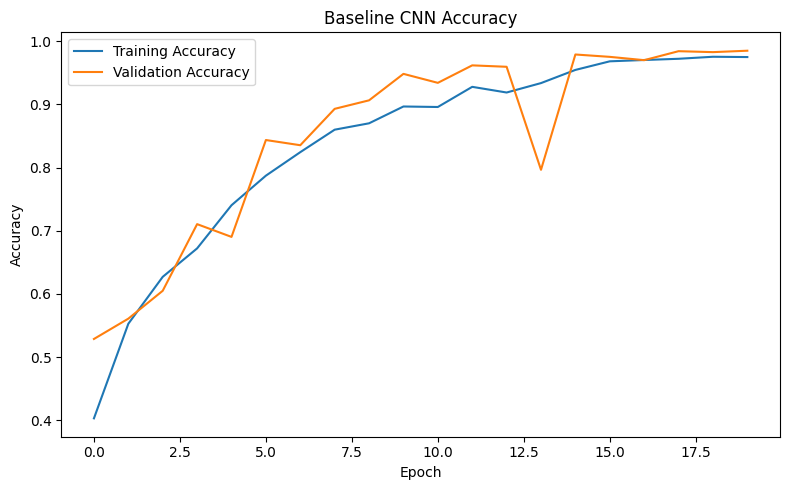

In [20]:
plt.figure(figsize=(8, 5))

plt.plot(baseline_history.history["accuracy"], label="Training Accuracy")
plt.plot(baseline_history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Baseline CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

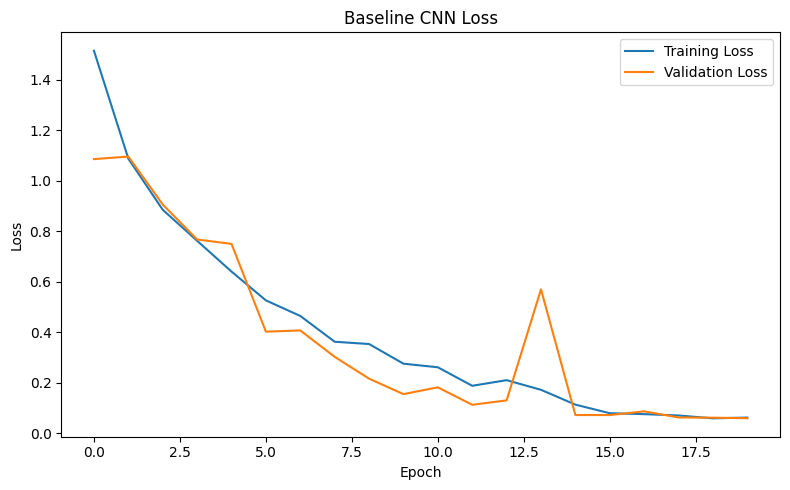

In [21]:
plt.figure(figsize=(8, 5))

plt.plot(baseline_history.history["loss"], label="Training Loss")
plt.plot(baseline_history.history["val_loss"], label="Validation Loss")

plt.title("Baseline CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

### Predict on the untouched test set

In [22]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = baseline_model.predict(images, verbose=0)

    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

### Test accuracy

In [23]:
test_accuracy = accuracy_score(y_true, y_pred)

print("Baseline Test Accuracy:", round(test_accuracy, 4))

Baseline Test Accuracy: 0.9903


### Precision, Recall and F1

In [24]:
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
)

print(report)

                        precision    recall  f1-score   support

      CCI_Caterpillars     1.0000    0.9932    0.9966       148
          CCI_Leaflets     0.9917    1.0000    0.9958       119
        Gray Leaf Spot     0.9937    0.9812    0.9874       320
        Healthy_Leaves     0.9474    0.9474    0.9474        19
              Leaf Rot     0.9800    0.9919    0.9859       247
WCLWD_DryingofLeaflets     0.9818    1.0000    0.9908       162
      WCLWD_Flaccidity     0.9938    1.0000    0.9969       160
       WCLWD_Yellowing     1.0000    0.9815    0.9907       162

              accuracy                         0.9903      1337
             macro avg     0.9860    0.9869    0.9864      1337
          weighted avg     0.9904    0.9903    0.9903      1337



### Confusion matrix

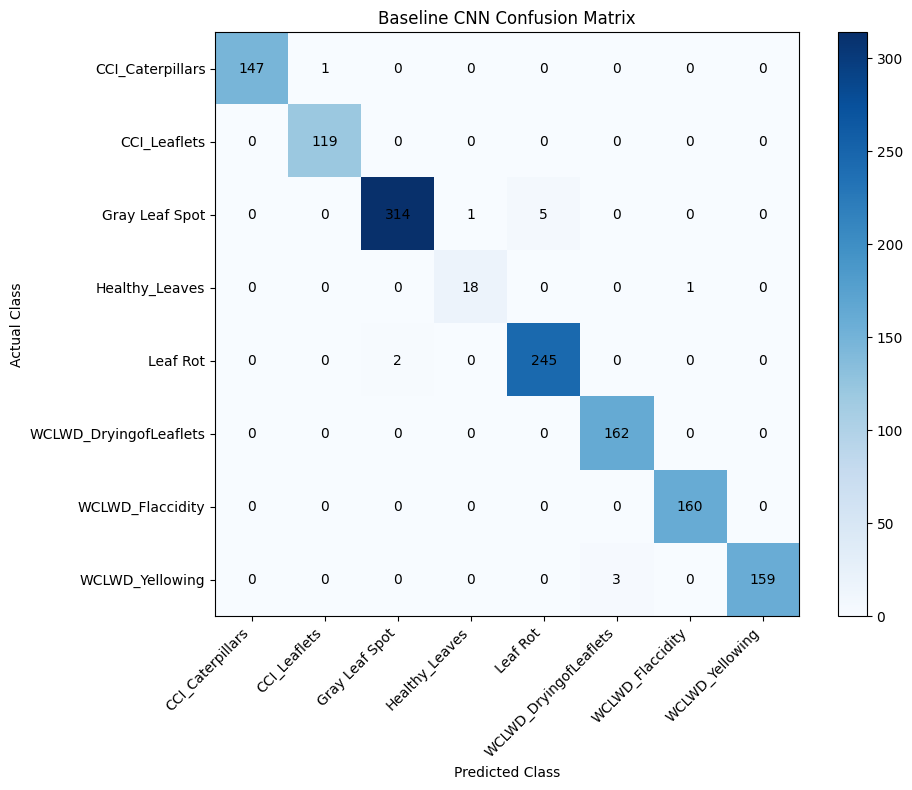

In [25]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))

plt.imshow(cm, interpolation="nearest", cmap="Blues")
plt.title("Baseline CNN Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_names))

plt.xticks(
    tick_marks,
    class_names,
    rotation=45,
    ha="right"
)

plt.yticks(
    tick_marks,
    class_names
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            color="black"
        )

plt.tight_layout()
plt.show()

### Save baseline results for later comparison

In [26]:
from sklearn.metrics import precision_recall_fscore_support

precision_macro, recall_macro, f1_macro, _ = (
    precision_recall_fscore_support(
        y_true,
        y_pred,
        average="macro"
    )
)

precision_weighted, recall_weighted, f1_weighted, _ = (
    precision_recall_fscore_support(
        y_true,
        y_pred,
        average="weighted"
    )
)

baseline_results = {
    "Model": "Custom CNN",
    "Test Accuracy": test_accuracy,
    "Macro Precision": precision_macro,
    "Macro Recall": recall_macro,
    "Macro F1": f1_macro,
    "Weighted F1": f1_weighted,
}

baseline_results

{'Model': 'Custom CNN',
 'Test Accuracy': 0.9902767389678384,
 'Macro Precision': 0.9860391219361507,
 'Macro Recall': 0.9869057474731817,
 'Macro F1': 0.9864369994518319,
 'Weighted F1': 0.9902749940699431}

## MobileNetV2

### Import MobileNetV2

In [27]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

### Build the pretrained base model

In [29]:
mobilenet_base = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

mobilenet_base.trainable = False

### Build our MobileNetV2 model

In [30]:
num_classes = len(class_names)

mobilenet_model = tf.keras.Sequential([
    layers.Input(shape=(224, 224, 3)),

    data_augmentation,

    layers.Lambda(preprocess_input),

    mobilenet_base,

    layers.GlobalAveragePooling2D(),

    layers.Dropout(0.3),

    layers.Dense(
        num_classes,
        activation="softmax"
    )
])

In [31]:
mobilenet_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │        10,248 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,268,232 (8.65 MB)

 Trainable params: 10,248 (40.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### Compile

In [32]:
mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

### Automatically save the best model

In [33]:
mobilenet_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "../backend/trained_models/mobilenetv2_transfer.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

### Train the transfer-learning stage

In [34]:
TRANSFER_EPOCHS = 10

In [35]:
mobilenet_history = mobilenet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=TRANSFER_EPOCHS,
    class_weight=class_weights,
    callbacks=mobilenet_callbacks
)

Epoch 1/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 787ms/step - accuracy: 0.6384 - loss: 0.9671
Epoch 1: val_loss improved from None to 0.27721, saving model to ../backend/trained_models/mobilenetv2_transfer.keras

Epoch 1: finished saving model to ../backend/trained_models/mobilenetv2_transfer.keras
195/195 ━━━━━━━━━━━━━━━━━━━━ 191s 944ms/step - accuracy: 0.7799 - loss: 0.5740 - val_accuracy: 0.9110 - val_loss: 0.2772 - learning_rate: 0.0010
Epoch 2/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 793ms/step - accuracy: 0.8924 - loss: 0.2688
Epoch 2: val_loss improved from 0.27721 to 0.19606, saving model to ../backend/trained_models/mobilenetv2_transfer.keras

Epoch 2: finished saving model to ../backend/trained_models/mobilenetv2_transfer.keras
195/195 ━━━━━━━━━━━━━━━━━━━━ 200s 938ms/step - accuracy: 0.9049 - loss: 0.2380 - val_accuracy: 0.9282 - val_loss: 0.1961 - learning_rate: 0.0010
Epoch 3/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 802ms/step - accuracy: 0.9258 - loss: 0.1801
Epoch 3: val_loss improved from

### evaluate the best MobileNetV2 model

In [37]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

mobilenet_best = tf.keras.models.load_model(
    "../backend/trained_models/mobilenetv2_transfer.keras",
    custom_objects={
        "preprocess_input": preprocess_input
    }
)

In [38]:
y_true_mobile = []
y_pred_mobile = []

for images, labels in test_ds:
    predictions = mobilenet_best.predict(images, verbose=0)

    y_true_mobile.extend(
        np.argmax(labels.numpy(), axis=1)
    )

    y_pred_mobile.extend(
        np.argmax(predictions, axis=1)
    )

y_true_mobile = np.array(y_true_mobile)
y_pred_mobile = np.array(y_pred_mobile)

In [39]:
from sklearn.metrics import accuracy_score, classification_report

mobile_test_accuracy = accuracy_score(
    y_true_mobile,
    y_pred_mobile
)

print(
    "MobileNetV2 Test Accuracy:",
    round(mobile_test_accuracy, 4)
)

print(
    classification_report(
        y_true_mobile,
        y_pred_mobile,
        target_names=class_names,
        digits=4
    )
)

MobileNetV2 Test Accuracy: 0.9738
                        precision    recall  f1-score   support

      CCI_Caterpillars     1.0000    1.0000    1.0000       148
          CCI_Leaflets     1.0000    1.0000    1.0000       119
        Gray Leaf Spot     1.0000    0.9594    0.9793       320
        Healthy_Leaves     0.6786    1.0000    0.8085        19
              Leaf Rot     0.9762    0.9960    0.9860       247
WCLWD_DryingofLeaflets     1.0000    0.9444    0.9714       162
      WCLWD_Flaccidity     0.9557    0.9437    0.9497       160
       WCLWD_Yellowing     0.9244    0.9815    0.9521       162

              accuracy                         0.9738      1337
             macro avg     0.9419    0.9781    0.9559      1337
          weighted avg     0.9766    0.9738    0.9744      1337



### Get the MobileNetV2 base from the loaded model

In [40]:
for i, layer in enumerate(mobilenet_best.layers):
    print(i, layer.name, type(layer).__name__)

0 data_augmentation Sequential
1 lambda Lambda
2 mobilenetv2_1.00_224 Functional
3 global_average_pooling2d_1 GlobalAveragePooling2D
4 dropout_1 Dropout
5 dense_1 Dense


## ResNet50

### Import ResNet50

In [52]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess

### Create the pretrained ResNet50 base

In [ ]:
resnet_base = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

resnet_base.trainable = False

 2031616/94765736 ━━━━━━━━━━━━━━━━━━━━ 58:55 38us/step